### Import libraries

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import statistics

from pyprojroot import here

### Load data

In [83]:
RAW_DATA_DIR = here() / "data" / "raw"
INTERIM_DATA_DIR = here() / "data" / "interim"
PROCESSED_DATA_DIR = here() / "data" / "processed"
RESULTS_DATA_DIR = here() / "results"

In [84]:
df = pd.read_csv(INTERIM_DATA_DIR/"crime_with_population.csv", encoding="latin-1")

In [85]:
df.columns

Index(['CVEGEO', 'year', 'state', 'municipality', 'crime_count', 'population',
       'log_pop'],
      dtype='object')

### Years summary 

In [86]:
years_df = df.groupby('year', as_index=False).agg({
    'CVEGEO': 'nunique',
    'crime_count': 'sum',
    'population': 'sum'
}).rename(columns={'CVEGEO': 'observations'})

In [87]:
zero_count_list = df[df["crime_count"] == 0]["year"].value_counts().reindex(years_df["year"], fill_value=0).tolist()

In [88]:
median_count_list = df[df['year'].isin(years_df['year'])].groupby('year')['crime_count'].median().tolist()

In [89]:
max_count_list = df[df['year'].isin(years_df['year'])].groupby('year')['crime_count'].max().tolist()


In [90]:
years_df['zero_count'] = zero_count_list
years_df['zero_proportion'] = round(years_df['zero_count'] / years_df['observations'], 3)
years_df['national_rate'] = years_df['crime_count'] / years_df['population'] * 100000
years_df['count_mean'] = round(years_df['crime_count'] / years_df['observations'], 3)
years_df['median_count'] = median_count_list
years_df['max_count'] = max_count_list

In [91]:
years_df

,year,observations,crime_count,population,zero_count,zero_proportion,national_rate,count_mean,median_count,max_count
0,2015,2478,49681,119008287.0,1322,0.533,41.745832,20.049,0.0,2261
1,2016,2478,48087,120342792.0,1335,0.539,39.958355,19.406,0.0,3013
2,2017,2478,65963,121677297.0,1253,0.506,54.211428,26.619,0.0,6851
3,2018,2478,83000,123011802.0,1208,0.487,67.473201,33.495,1.0,7457
4,2019,2478,94038,124346307.0,1098,0.443,75.625889,37.949,1.0,7359
5,2020,2478,94598,126004259.0,1113,0.449,75.075240,38.175,1.0,12480
6,2021,2478,101268,127015317.0,1082,0.437,79.728967,40.867,1.0,20787
7,2022,2478,106236,128349822.0,1037,0.418,82.770664,42.872,1.0,18950
8,2023,2478,108117,129684327.0,1046,0.422,83.369365,43.631,1.0,15622
9,2024,2478,110143,131018832.0,1093,0.441,84.066541,44.448,1.0,15648


### Crime count plots

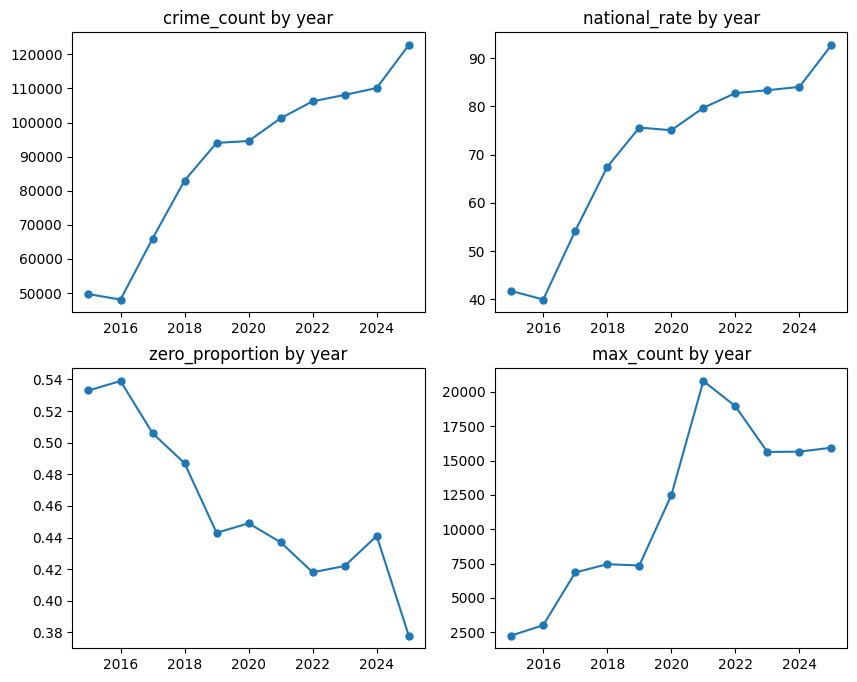

In [66]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
axes[0, 0].plot(years_df['year'], years_df['crime_count'], marker='o', markersize=5)
axes[0, 0].set_title('crime_count by year')

axes[0, 1].plot(years_df['year'], years_df['national_rate'], marker='o', markersize=5)
axes[0, 1].set_title('national_rate by year')

axes[1, 0].plot(years_df['year'], years_df['zero_proportion'], marker='o', markersize=5)
axes[1, 0].set_title('zero_proportion by year')

axes[1, 1].plot(years_df['year'], years_df['max_count'], marker='o', markersize=5)
axes[1, 1].set_title('max_count by year')

plt.savefig(RESULTS_DATA_DIR/"temporal_diagnosis_results/crime_count_plots.png", dpi=300, bbox_inches="tight")
plt.show()

### Spearman correlation test

In [67]:
def spearman_corr(year_1: int, lag: int):
    a = df[df['year'] == year_1].copy().reset_index(drop=True)
    b = df[df['year'] == (year_1 + lag)].copy().reset_index(drop=True)
    rho, p_value = spearmanr(a['crime_count'], b['crime_count'])
    print(f'Spearman correlation {year_1} and {year_1 + lag} (lag {lag}) p_value: {p_value:.4f}, rho: {rho:.4f}') 

In [68]:
year_list = df['year'].unique().tolist()

***** Lag 1 results *****

In [69]:
for i, year in enumerate(year_list):
    try:
        spearman_corr(year, 1) 
    except ValueError:
        print(f"Stopping loop early at year: {year} (Index: {i})")
        break  

Spearman correlation 2015 and 2016 (lag 1) p_value: 0.0000, rho: 0.7486
Spearman correlation 2016 and 2017 (lag 1) p_value: 0.0000, rho: 0.7939
Spearman correlation 2017 and 2018 (lag 1) p_value: 0.0000, rho: 0.7956
Spearman correlation 2018 and 2019 (lag 1) p_value: 0.0000, rho: 0.8013
Spearman correlation 2019 and 2020 (lag 1) p_value: 0.0000, rho: 0.7994
Spearman correlation 2020 and 2021 (lag 1) p_value: 0.0000, rho: 0.8244
Spearman correlation 2021 and 2022 (lag 1) p_value: 0.0000, rho: 0.8208
Spearman correlation 2022 and 2023 (lag 1) p_value: 0.0000, rho: 0.8049
Spearman correlation 2023 and 2024 (lag 1) p_value: 0.0000, rho: 0.8333
Spearman correlation 2024 and 2025 (lag 1) p_value: 0.0000, rho: 0.8236
Stopping loop early at year: 2025 (Index: 10)


***** Lag 2 results *****

In [70]:
for i, year in enumerate(year_list):
    try:
        spearman_corr(year, 2) 
    except ValueError:
        print(f"Stopping loop early at year: {year} (Index: {i})")
        break  

Spearman correlation 2015 and 2017 (lag 2) p_value: 0.0000, rho: 0.7552
Spearman correlation 2016 and 2018 (lag 2) p_value: 0.0000, rho: 0.7659
Spearman correlation 2017 and 2019 (lag 2) p_value: 0.0000, rho: 0.7851
Spearman correlation 2018 and 2020 (lag 2) p_value: 0.0000, rho: 0.7940
Spearman correlation 2019 and 2021 (lag 2) p_value: 0.0000, rho: 0.8014
Spearman correlation 2020 and 2022 (lag 2) p_value: 0.0000, rho: 0.7873
Spearman correlation 2021 and 2023 (lag 2) p_value: 0.0000, rho: 0.7985
Spearman correlation 2022 and 2024 (lag 2) p_value: 0.0000, rho: 0.7813
Spearman correlation 2023 and 2025 (lag 2) p_value: 0.0000, rho: 0.8102
Stopping loop early at year: 2024 (Index: 9)


***** Lag 3 results *****

In [71]:
for i, year in enumerate(year_list):
    try:
        spearman_corr(year, 3) 
    except ValueError:
        print(f"Stopping loop early at year: {year} (Index: {i})")
        break  

Spearman correlation 2015 and 2018 (lag 3) p_value: 0.0000, rho: 0.7187
Spearman correlation 2016 and 2019 (lag 3) p_value: 0.0000, rho: 0.7447
Spearman correlation 2017 and 2020 (lag 3) p_value: 0.0000, rho: 0.7709
Spearman correlation 2018 and 2021 (lag 3) p_value: 0.0000, rho: 0.7715
Spearman correlation 2019 and 2022 (lag 3) p_value: 0.0000, rho: 0.7660
Spearman correlation 2020 and 2023 (lag 3) p_value: 0.0000, rho: 0.7774
Spearman correlation 2021 and 2024 (lag 3) p_value: 0.0000, rho: 0.7800
Spearman correlation 2022 and 2025 (lag 3) p_value: 0.0000, rho: 0.7888
Stopping loop early at year: 2023 (Index: 8)


### Persistance of crime ocurrance

In [72]:
m_df = df.drop(columns={'state', 'municipality'}).copy()

In [73]:
m_df_non_zero = m_df[m_df['crime_count'] != 0].reset_index(drop=True)
quartiles = statistics.quantiles(m_df_non_zero['crime_count'], n=4)
quartiles

[2.0, 5.0, 17.0]

In [74]:
m_df['q0'] = np.where(m_df['crime_count'] == 0, 1, 0)
m_df['q1'] = np.where((m_df['crime_count'] > 0) & (m_df['crime_count'] < quartiles[0]), 1, 0)
m_df['q2'] = np.where((m_df['crime_count'] > quartiles[0]) & (m_df['crime_count'] < quartiles[1]), 1, 0)
m_df['q3'] = np.where((m_df['crime_count'] > quartiles[1]) & (m_df['crime_count'] < quartiles[2]), 1, 0)
m_df['q4'] = np.where(m_df['crime_count'] > quartiles[2], 1, 0)

In [75]:
state_cols = ["q0", "q1", "q2", "q3", "q4"]
n_states = len(state_cols)

In [76]:
m_df["n_active"] = m_df[state_cols].sum(axis=1)
print(m_df["n_active"].value_counts()) 

m_df["crime_state"] = m_df[state_cols].idxmax(axis=1).str[1:].astype(int)
m_df["crime_state"] = m_df["crime_state"].where(m_df["n_active"] == 1) 

n_active
1    24638
0     2620
Name: count, dtype: int64


In [77]:
m_df = m_df.sort_values(["CVEGEO", "year"])
m_df["next_state"] = m_df.groupby("CVEGEO")["crime_state"].shift(-1)
m_df["next_year"] = m_df.groupby("CVEGEO")["year"].shift(-1)

pairs = m_df[m_df["next_year"] == m_df["year"] + 1]
pairs = pairs.dropna(subset=["crime_state", "next_state"])
print("Transition pairs:", len(pairs))

Transition pairs: 20472


In [78]:
counts_by_pair = {}
probs_by_pair = {}

for year in sorted(pairs["year"].unique()):
    sub = pairs[pairs["year"] == year]

    counts = pd.crosstab(sub["crime_state"].astype(int), sub["next_state"].astype(int))
    counts = counts.reindex(index=range(n_states), columns=range(n_states), fill_value=0)

    probs = counts.div(counts.sum(axis=1), axis=0)

    label = f"{year}-{year + 1}"
    counts_by_pair[label] = counts
    probs_by_pair[label] = probs

    print(f"\n===== {label} | pairs used: {len(sub)} =====")
    print(counts)
    print(probs.round(3))
    print("Row sums:", probs.sum(axis=1).round(3).tolist())


===== 2015-2016 | pairs used: 2106 =====
next_state      0    1   2    3    4
crime_state                         
0            1076  144  36   13    2
1             137   70  21    9    1
2              48   36  36   29    4
3              18   19  30  111   32
4               0    2   2   31  199
next_state       0      1      2      3      4
crime_state                                   
0            0.847  0.113  0.028  0.010  0.002
1            0.576  0.294  0.088  0.038  0.004
2            0.314  0.235  0.235  0.190  0.026
3            0.086  0.090  0.143  0.529  0.152
4            0.000  0.009  0.009  0.132  0.850
Row sums: [1.0, 1.0, 1.0, 1.0, 1.0]

===== 2016-2017 | pairs used: 2084 =====
next_state      0    1   2    3    4
crime_state                         
0            1067  153  51   11    0
1             118   61  53   16    1
2              20   21  29   36    4
3               5    6  24  116   49
4               0    0   0   21  222
next_state       0      1      2 

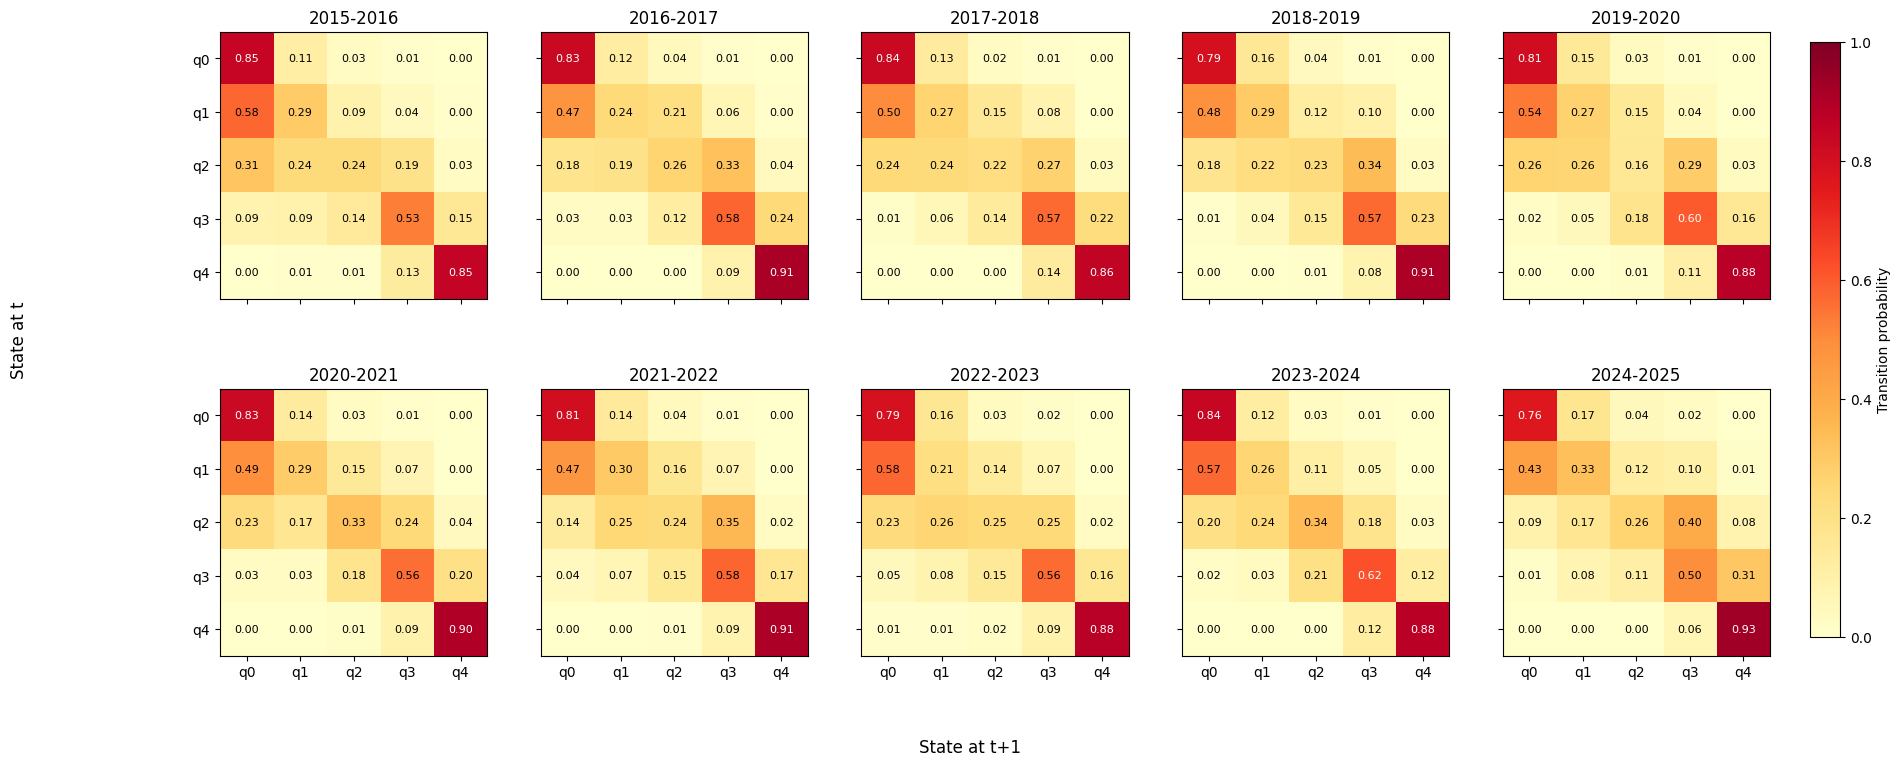

In [79]:
labels = list(probs_by_pair.keys())   # "2015-2016", "2016-2017", ...
state_names = [f"q{i}" for i in range(n_states)]

n_rows, n_cols = 2, 5
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 8.5), sharex=True, sharey=True)
axes = axes.flatten()

cmap = plt.cm.YlOrRd.copy()
cmap.set_bad("lightgrey")   # NaN cells (rows with no observations)

for ax, label in zip(axes, labels):
    m = probs_by_pair[label].values
    im = ax.imshow(m, cmap=cmap, vmin=0, vmax=1)   # same 0-1 scale in every panel

    ax.set_title(label)
    ax.set_xticks(range(n_states))
    ax.set_yticks(range(n_states))
    ax.set_xticklabels(state_names)
    ax.set_yticklabels(state_names)

    # Write the probability inside each cell
    for i in range(n_states):
        for j in range(n_states):
            if not np.isnan(m[i, j]):
                text_color = "white" if m[i, j] > 0.6 else "black"
                ax.text(j, i, f"{m[i, j]:.2f}", ha="center", va="center",
                        color=text_color, fontsize=8)

# Hide unused panels, if any
for ax in axes[len(labels):]:
    ax.axis("off")

fig.supxlabel("State at t+1")
fig.supylabel("State at t")

# One shared colorbar
fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Transition probability")

plt.savefig(RESULTS_DATA_DIR/"temporal_diagnosis_results/transition_heatmaps.png", dpi=300, bbox_inches="tight")
plt.show()

In [80]:
counts = pd.crosstab(pairs["crime_state"].astype(int), pairs["next_state"].astype(int))
counts = counts.reindex(index=range(n_states), columns=range(n_states), fill_value=0)

probs = counts.div(counts.sum(axis=1), axis=0)

print("\nCounts:\n", counts)
print("\nTransition matrix:\n", probs.round(3))
print("\nRow sums:\n", probs.sum(axis=1))


Counts:
 next_state      0     1    2     3     4
crime_state                             
0            8983  1530  366   117     6
1            1334   716  366   179     7
2             295   321  364   408    52
3              64   126  349  1292   449
4               4     6   23   309  2806

Transition matrix:
 next_state       0      1      2      3      4
crime_state                                   
0            0.816  0.139  0.033  0.011  0.001
1            0.513  0.275  0.141  0.069  0.003
2            0.205  0.223  0.253  0.283  0.036
3            0.028  0.055  0.153  0.567  0.197
4            0.001  0.002  0.007  0.098  0.891

Row sums:
 crime_state
0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
dtype: float64


next_state      0     1    2     3     4
crime_state                             
0            8983  1530  366   117     6
1            1334   716  366   179     7
2             295   321  364   408    52
3              64   126  349  1292   449
4               4     6   23   309  2806
next_state       0      1      2      3      4
crime_state                                   
0            0.816  0.139  0.033  0.011  0.001
1            0.513  0.275  0.141  0.069  0.003
2            0.205  0.223  0.253  0.283  0.036
3            0.028  0.055  0.153  0.567  0.197
4            0.001  0.002  0.007  0.098  0.891
Row sums: [1.0, 1.0, 1.0, 1.0, 1.0]


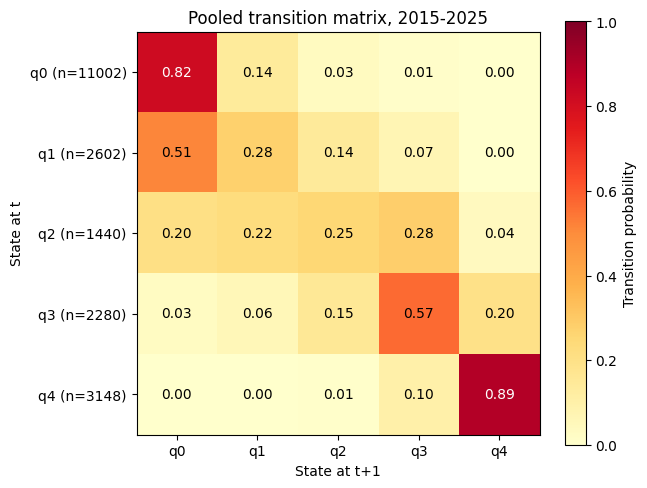

In [81]:
import numpy as np
import matplotlib.pyplot as plt

pooled_counts = sum(counts_by_pair.values())
pooled_probs = pooled_counts.div(pooled_counts.sum(axis=1), axis=0)

print(pooled_counts)
print(pooled_probs.round(3))
print("Row sums:", pooled_probs.sum(axis=1).round(3).tolist())


m = pooled_probs.values
row_totals = pooled_counts.sum(axis=1).values
state_names = [f"q{i}" for i in range(n_states)]

cmap = plt.cm.YlOrRd.copy()
cmap.set_bad("lightgrey")   

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(m, cmap=cmap, vmin=0, vmax=1)

ax.set_title("Pooled transition matrix, 2015-2025")
ax.set_xticks(range(n_states))
ax.set_yticks(range(n_states))
ax.set_xticklabels(state_names)
ax.set_yticklabels([f"{s} (n={n})" for s, n in zip(state_names, row_totals)])
ax.set_xlabel("State at t+1")
ax.set_ylabel("State at t")

for i in range(n_states):
    for j in range(n_states):
        if not np.isnan(m[i, j]):
            text_color = "white" if m[i, j] > 0.6 else "black"
            ax.text(j, i, f"{m[i, j]:.2f}", ha="center", va="center", color=text_color)

fig.colorbar(im, ax=ax, label="Transition probability")

plt.savefig(RESULTS_DATA_DIR/"temporal_diagnosis_results/transition_heatmap_pooled.png", dpi=300, bbox_inches="tight")
plt.show()